In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing tools
from sklearn.preprocessing import (
    LabelEncoder,        # Binary / label encoding
    OrdinalEncoder,      # Ordinal (ordered) encoding
    OneHotEncoder,       # One-hot encoding
    MinMaxScaler,        # Scale features to [0, 1]
    StandardScaler       # Z-score normalization (mean=0, std=1)
)
from sklearn.impute import SimpleImputer  # Fill missing values

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

print('✅ All libraries imported!')

✅ All libraries imported!


In [7]:
#df = pd.read_csv("Student Depression Dataset.csv")

In [8]:
#df.head()

In [9]:
#df.shape


In [10]:
#df.columns

In [11]:
raw_df = pd.read_csv("Student Depression Dataset.csv")

In [12]:
cols_to_keep = ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 
                'Sleep Duration', 'Financial Stress', 'Work/Study Hours', 'Study Satisfaction','Depression']
df = raw_df[cols_to_keep].copy()  # .copy() avoids SettingWithCopyWarning


In [13]:
df.shape

(27901, 9)

In [14]:
raw_df.shape

(27901, 18)

In [15]:
df.isnull().sum()

Gender                0
Age                   0
Academic Pressure     0
Work Pressure         0
Sleep Duration        0
Financial Stress      3
Work/Study Hours      0
Study Satisfaction    0
Depression            0
dtype: int64

In [16]:
df['Financial Stress']

0        1.0
1        2.0
2        1.0
3        5.0
4        1.0
        ... 
27896    1.0
27897    3.0
27898    2.0
27899    5.0
27900    3.0
Name: Financial Stress, Length: 27901, dtype: float64

In [17]:
df['Financial Stress'].value_counts()

Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
Name: count, dtype: int64

In [18]:
df['Financial Stress'].unique()

array([ 1.,  2.,  5.,  3.,  4., nan])

In [19]:
df['Financial Stress'].mode()

0    5.0
Name: Financial Stress, dtype: float64

In [20]:
df['Financial Stress'].dtype

dtype('float64')

In [21]:
df.isnull().sum()


Gender                0
Age                   0
Academic Pressure     0
Work Pressure         0
Sleep Duration        0
Financial Stress      3
Work/Study Hours      0
Study Satisfaction    0
Depression            0
dtype: int64

In [22]:
# --- Method : Sklearn SimpleImputer (recommended for pipelines) ---
df_sklearn = df.copy()

# Numeric imputer
num_imputer = SimpleImputer(strategy='median')
df_sklearn[['Financial Stress']] = num_imputer.fit_transform(df_sklearn[['Age']])

print('✅ Imputation complete with SimpleImputer')
print('\nMissing values after imputation:')
print(df_sklearn.isnull().sum())

# Use the sklearn version going forward
df_clean = df_sklearn.copy()

✅ Imputation complete with SimpleImputer

Missing values after imputation:
Gender                0
Age                   0
Academic Pressure     0
Work Pressure         0
Sleep Duration        0
Financial Stress      0
Work/Study Hours      0
Study Satisfaction    0
Depression            0
dtype: int64


In [23]:
df_sklearn.isnull().sum()

Gender                0
Age                   0
Academic Pressure     0
Work Pressure         0
Sleep Duration        0
Financial Stress      0
Work/Study Hours      0
Study Satisfaction    0
Depression            0
dtype: int64

In [24]:
#LABEL ENCODING

df_label= df_clean.copy()

In [25]:
le = LabelEncoder()
df_label['Gender_encoded'] = le.fit_transform(df_label['Gender'])

print('=== Label Encoding: Gender ===')
print(f'Classes learned: {le.classes_}') 
print(f'Encoding map   : Female→{le.transform(["Female"])[0]}, Male→{le.transform(["Male"])[0]}')




# Demonstrate inverse_transform
sample_encoded = [0, 1, 0, 1]
print(f'\nDecode [0,1,0,1]: {le.inverse_transform(sample_encoded)}')


=== Label Encoding: Gender ===
Classes learned: ['Female' 'Male']
Encoding map   : Female→0, Male→1

Decode [0,1,0,1]: ['Female' 'Male' 'Female' 'Male']


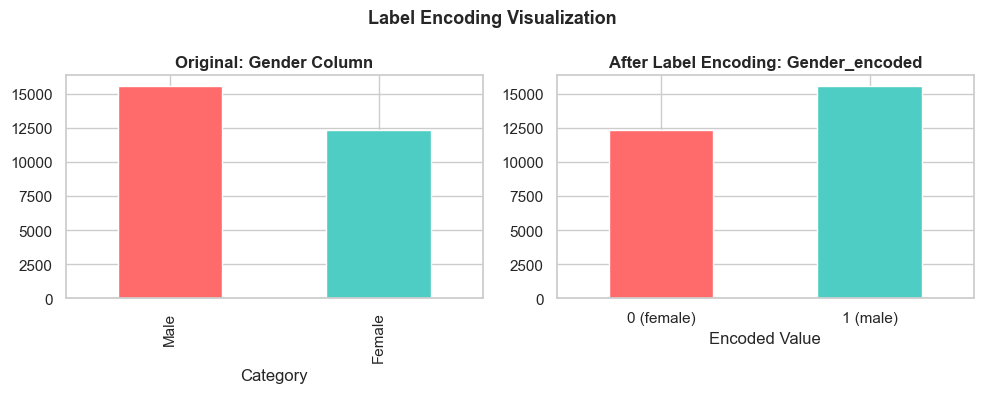

In [26]:
# Visualize the encoding effect
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_label['Gender'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Original: Gender Column', fontweight='bold')
axes[0].set_xlabel('Category')

df_label['Gender_encoded'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('After Label Encoding: Gender_encoded', fontweight='bold')
axes[1].set_xlabel('Encoded Value')
axes[1].set_xticklabels(['0 (female)', '1 (male)'], rotation=0)

plt.suptitle('Label Encoding Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show() 

<Axes: >

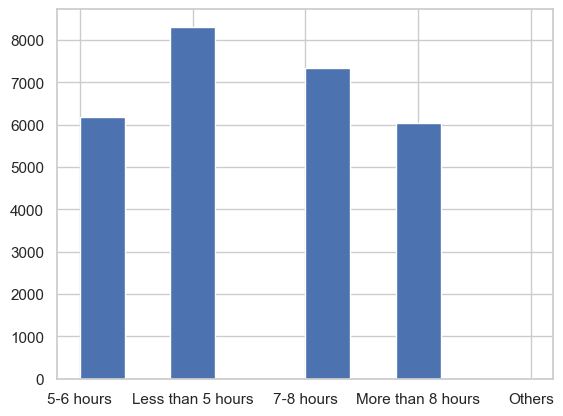

In [27]:
df['Sleep Duration'].hist()

In [33]:
df_ordinal = df_clean.copy()
df_ordinal = df_ordinal[df_ordinal['Sleep Duration'] != 'Others']

In [34]:
#Manual Ordinal Encoding , mapping
sleep_map = {
    'Less than 5 hours': 0,
    '5-6 hours': 1,
    '7-8 hours': 2,
    'More than 8 hours': 3
}

df_ordinal['SleepCategory_encoded'] = df_ordinal['Sleep Duration'].map(sleep_map)

In [35]:
df_ordinal[['Sleep Duration', 'SleepCategory_encoded']].drop_duplicates()


,Sleep Duration,SleepCategory_encoded
0,5-6 hours,1
2,Less than 5 hours,0
3,7-8 hours,2
15,More than 8 hours,3


In [36]:
df_ordinal['Sleep Duration'].value_counts()

Sleep Duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Name: count, dtype: int64

In [37]:
df_ordinal.head()

,Gender,Age,Academic Pressure,Work Pressure,Sleep Duration,Financial Stress,Work/Study Hours,Study Satisfaction,Depression,SleepCategory_encoded
0,Male,33.0,5.0,0.0,5-6 hours,33.0,3.0,2.0,1,1
1,Female,24.0,2.0,0.0,5-6 hours,24.0,3.0,5.0,0,1
2,Male,31.0,3.0,0.0,Less than 5 hours,31.0,9.0,5.0,0,0
3,Female,28.0,3.0,0.0,7-8 hours,28.0,4.0,2.0,1,2
4,Female,25.0,4.0,0.0,5-6 hours,25.0,1.0,3.0,0,1


In [38]:
df_ordinal.info()

<class 'pandas.DataFrame'>
Index: 27883 entries, 0 to 27900
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 27883 non-null  str    
 1   Age                    27883 non-null  float64
 2   Academic Pressure      27883 non-null  float64
 3   Work Pressure          27883 non-null  float64
 4   Sleep Duration         27883 non-null  str    
 5   Financial Stress       27883 non-null  float64
 6   Work/Study Hours       27883 non-null  float64
 7   Study Satisfaction     27883 non-null  float64
 8   Depression             27883 non-null  int64  
 9   SleepCategory_encoded  27883 non-null  int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 2.3 MB


In [39]:
df_ordinal.columns

Index(['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'Sleep Duration',
       'Financial Stress', 'Work/Study Hours', 'Study Satisfaction',
       'Depression', 'SleepCategory_encoded'],
      dtype='str')

In [40]:
df_clean.columns

Index(['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'Sleep Duration',
       'Financial Stress', 'Work/Study Hours', 'Study Satisfaction',
       'Depression'],
      dtype='str')

In [41]:
df['Depression'].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [42]:

df_model = df_clean.copy()

df_model['Gender_encoded'] = df_label['Gender_encoded']
df_model['SleepCategory_encoded'] = df_ordinal['SleepCategory_encoded']



In [43]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 27901 non-null  str    
 1   Age                    27901 non-null  float64
 2   Academic Pressure      27901 non-null  float64
 3   Work Pressure          27901 non-null  float64
 4   Sleep Duration         27901 non-null  str    
 5   Financial Stress       27901 non-null  float64
 6   Work/Study Hours       27901 non-null  float64
 7   Study Satisfaction     27901 non-null  float64
 8   Depression             27901 non-null  int64  
 9   Gender_encoded         27901 non-null  int64  
 10  SleepCategory_encoded  27883 non-null  float64
dtypes: float64(7), int64(2), str(2)
memory usage: 2.3 MB


In [44]:
#dropping gender and sleep duration column as it is already encoded 
#encoded values are in gender_encoded and SleepCategory_encoded column


df_model[['Gender','Gender_encoded','Sleep Duration','SleepCategory_encoded']].head(20)

,Gender,Gender_encoded,Sleep Duration,SleepCategory_encoded
0,Male,1,5-6 hours,1.0
1,Female,0,5-6 hours,1.0
2,Male,1,Less than 5 hours,0.0
3,Female,0,7-8 hours,2.0
4,Female,0,5-6 hours,1.0
5,Male,1,Less than 5 hours,0.0
6,Male,1,7-8 hours,2.0
7,Female,0,Less than 5 hours,0.0
8,Male,1,7-8 hours,2.0
9,Male,1,Less than 5 hours,0.0


In [45]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 27901 non-null  str    
 1   Age                    27901 non-null  float64
 2   Academic Pressure      27901 non-null  float64
 3   Work Pressure          27901 non-null  float64
 4   Sleep Duration         27901 non-null  str    
 5   Financial Stress       27901 non-null  float64
 6   Work/Study Hours       27901 non-null  float64
 7   Study Satisfaction     27901 non-null  float64
 8   Depression             27901 non-null  int64  
 9   Gender_encoded         27901 non-null  int64  
 10  SleepCategory_encoded  27883 non-null  float64
dtypes: float64(7), int64(2), str(2)
memory usage: 2.3 MB


In [46]:
df_model = df_model.drop(columns=['Gender', 'Sleep Duration'])

In [47]:
df_model.info()


<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    27901 non-null  float64
 1   Academic Pressure      27901 non-null  float64
 2   Work Pressure          27901 non-null  float64
 3   Financial Stress       27901 non-null  float64
 4   Work/Study Hours       27901 non-null  float64
 5   Study Satisfaction     27901 non-null  float64
 6   Depression             27901 non-null  int64  
 7   Gender_encoded         27901 non-null  int64  
 8   SleepCategory_encoded  27883 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.9 MB


In [48]:
df_model.isnull().sum()

Age                       0
Academic Pressure         0
Work Pressure             0
Financial Stress          0
Work/Study Hours          0
Study Satisfaction        0
Depression                0
Gender_encoded            0
SleepCategory_encoded    18
dtype: int64

In [49]:
df_model['SleepCategory_encoded'] = df_model['SleepCategory_encoded'].fillna(
    df_model['SleepCategory_encoded'].median()
)


In [50]:
df_model.isnull().sum()

Age                      0
Academic Pressure        0
Work Pressure            0
Financial Stress         0
Work/Study Hours         0
Study Satisfaction       0
Depression               0
Gender_encoded           0
SleepCategory_encoded    0
dtype: int64

In [51]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    27901 non-null  float64
 1   Academic Pressure      27901 non-null  float64
 2   Work Pressure          27901 non-null  float64
 3   Financial Stress       27901 non-null  float64
 4   Work/Study Hours       27901 non-null  float64
 5   Study Satisfaction     27901 non-null  float64
 6   Depression             27901 non-null  int64  
 7   Gender_encoded         27901 non-null  int64  
 8   SleepCategory_encoded  27901 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.9 MB


In [52]:
# # Apply scaling to numeric columns
# numeric_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'Financial Stress','Work/Study Hours','Study Satisfaction']

# # --- MinMax Scaler ---
# mm_scaler = MinMaxScaler()  # Scales to [0, 1]
# df_minmax = df_clean.copy()
# df_minmax[numeric_cols] = mm_scaler.fit_transform(df_clean[numeric_cols])

# # --- Standard Scaler ---
# std_scaler = StandardScaler()  # Scales to mean=0, std=1
# df_standard = df_clean.copy()
# df_standard[numeric_cols] = std_scaler.fit_transform(df_clean[numeric_cols])

# print('=== Original Stats ===')
# print(df_clean[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

# print('\n=== After MinMaxScaler (all in [0,1]) ===')
# print(df_minmax[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

# print('\n=== After StandardScaler (mean≈0, std≈1) ===')
# print(df_standard[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2))

In [53]:
#Using Standard Scaler 

scaler = StandardScaler()

numeric_cols = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'Financial Stress',
    'Work/Study Hours',
    'Study Satisfaction'
]

df_model[numeric_cols] = scaler.fit_transform(df_model[numeric_cols])

In [54]:
df_model.head()

,Age,Academic Pressure,Work Pressure,Financial Stress,Work/Study Hours,Study Satisfaction,Depression,Gender_encoded,SleepCategory_encoded
0,1.463165,1.345543,-0.009777,1.463165,-1.121213,-0.693425,1,1,1.0
1,-0.371474,-0.826104,-0.009777,-0.371474,-1.121213,1.510636,0,0,1.0
2,1.055467,-0.102222,-0.009777,1.055467,0.497095,1.510636,0,1,0.0
3,0.443921,-0.102222,-0.009777,0.443921,-0.851495,-0.693425,1,0,2.0
4,-0.167625,0.621660,-0.009777,-0.167625,-1.660650,0.041262,0,0,1.0


In [55]:
print(f'Shape:{df_model.shape}')
print(f'Columns:df_model.columns')
print(f'Null Values:{df_model.isnull().sum().sum()}')
df_model.head(11)

Shape:(27901, 9)
Columns:df_model.columns
Null Values:0


,Age,Academic Pressure,Work Pressure,Financial Stress,Work/Study Hours,Study Satisfaction,Depression,Gender_encoded,SleepCategory_encoded
0,1.463165,1.345543,-0.009777,1.463165,-1.121213,-0.693425,1,1,1.0
1,-0.371474,-0.826104,-0.009777,-0.371474,-1.121213,1.510636,0,0,1.0
2,1.055467,-0.102222,-0.009777,1.055467,0.497095,1.510636,0,1,0.0
3,0.443921,-0.102222,-0.009777,0.443921,-0.851495,-0.693425,1,0,2.0
4,-0.167625,0.621660,-0.009777,-0.167625,-1.660650,0.041262,0,0,1.0
5,0.647770,-0.826104,-0.009777,0.647770,-0.851495,0.041262,0,1,0.0
6,0.851619,-0.102222,-0.009777,0.851619,-1.660650,0.775949,0,1,2.0
7,0.851619,-0.826104,-0.009777,0.851619,-1.930368,0.775949,0,0,0.0
8,0.443921,-0.102222,-0.009777,0.443921,1.306249,-1.428112,1,1,2.0
9,1.055467,-0.826104,-0.009777,1.055467,-1.390931,0.041262,1,1,0.0


In [ ]:
# Save the transformed dataset for model training


print('\n📌 Summary of all transformations applied:')
print('1. Missing values filled')
print( '2. Sex: Label Encoded ')
print('3. Numeric features: Scaled using Standard Scaler')
print()



📌 Summary of all transformations applied:
1. Missing values filled
2. Sex: Label Encoded 
3. Numeric features: Scaled using Standard Scaler

Next: Notebook 3 — Model Training with Classification Models


In [ ]:
# Model Training Starts from here on 
X = df_model.drop('Depression', axis=1)
y = df_model['Depression']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7582870453323777

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7582870453323777
              precision    recall  f1-score   support

           0       0.73      0.67      0.70      2343
           1       0.78      0.82      0.80      3238

    accuracy                           0.76      5581
   macro avg       0.75      0.75      0.75      5581
weighted avg       0.76      0.76      0.76      5581

[[1571  772]
 [ 577 2661]]
